In [1]:
# Cell 1 — Setup: load baseline and sessions
import sys, glob, joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style
matplotlib.style.use('dark_background')
sys.path.insert(0, '../src')
from features import load_events, compute_dwell, compute_flight, extract_features

baseline  = joblib.load('../models/user_baseline.pkl')
model     = baseline['model']
scaler    = baseline['scaler']

print(f"Baseline loaded ✓")
print(f"Threshold : {baseline['threshold']:.4f}")
print(f"Mean score: {baseline['mean_score']:.4f}")

Baseline loaded ✓
Threshold : -0.0320
Mean score: 0.0576


  Loaded 2576 events from ../data/raw\session_20260312_012340.csv
  Loaded 2306 events from ../data/raw\session_20260312_013405.csv
  Loaded 2206 events from ../data/raw\session_20260312_014005.csv


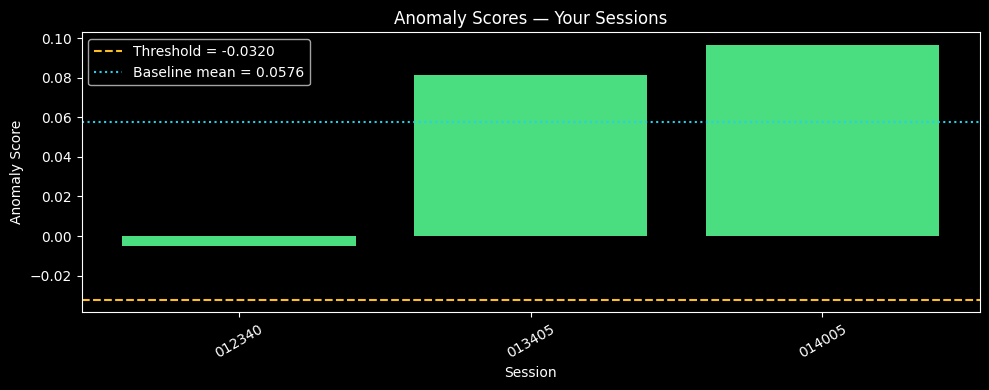

Green bars = normal  (3/3)
Red bars   = anomaly (0/3)


In [2]:
# Cell 2 — Score all sessions, plot distribution
files  = sorted(glob.glob('../data/raw/session_*.csv'))
scores = []

for f in files:
    df        = load_events(f)
    dwell_df  = compute_dwell(df)
    flight_df = compute_flight(df)
    feat      = extract_features(dwell_df, flight_df)
    X         = np.array([list(feat.values())])

    n_cmu = scaler.n_features_in_
    if X.shape[1] < n_cmu:
        X = np.hstack([X, np.zeros((X.shape[0], n_cmu - X.shape[1]))])
    X_sc = scaler.transform(X[:, :n_cmu])
    scores.append(model.decision_function(X_sc)[0])

scores = np.array(scores)
threshold = baseline['threshold']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(scores)), scores, color=[
    '#4ade80' if s > threshold else '#f87171' for s in scores
])
ax.axhline(threshold, color='#fbbf24', linestyle='--',
           label=f'Threshold = {threshold:.4f}')
ax.axhline(baseline['mean_score'], color='#22d3ee', linestyle=':',
           label=f'Baseline mean = {baseline["mean_score"]:.4f}')
ax.set_title('Anomaly Scores — Your Sessions', color='white')
ax.set_xlabel('Session'); ax.set_ylabel('Anomaly Score')
ax.set_xticks(range(len(files)))
ax.set_xticklabels([f.split('_')[-1][:6] for f in files], rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/anomaly_scores.png', dpi=120)
plt.show()
print(f"Green bars = normal  ({(scores > threshold).sum()}/{len(scores)})")
print(f"Red bars   = anomaly ({(scores <= threshold).sum()}/{len(scores)})")

c:\Users\gmnai\Desktop\Biosync\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  Loaded 2576 events from ../data/raw\session_20260312_012340.csv
  Loaded 2306 events from ../data/raw\session_20260312_013405.csv
  Loaded 2206 events from ../data/raw\session_20260312_014005.csv


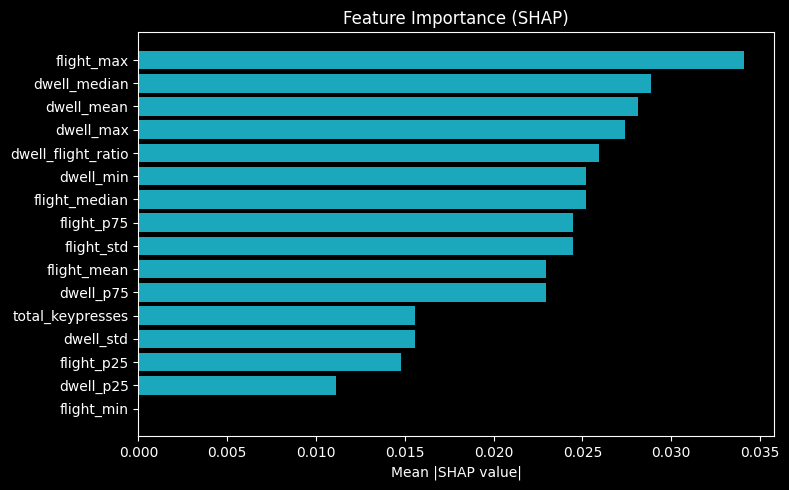

Top 3 features:
  flight_max                0.0341
  dwell_median              0.0289
  dwell_mean                0.0281


In [3]:
# Cell 3 — SHAP feature importance (for report)
import shap

# Build feature matrix from all sessions
X_all = []
feat_names = None
for f in files:
    df       = load_events(f)
    dw       = compute_dwell(df)
    fl       = compute_flight(df)
    feat     = extract_features(dw, fl)
    feat_names = list(feat.keys())
    X_all.append(list(feat.values()))

X_all = np.array(X_all)
n_cmu = scaler.n_features_in_
if X_all.shape[1] < n_cmu:
    X_all = np.hstack([X_all, np.zeros((X_all.shape[0], n_cmu - X_all.shape[1]))])
X_sc = scaler.transform(X_all[:, :n_cmu])

# Compute SHAP values
explainer  = shap.Explainer(model, X_sc)
shap_vals  = explainer(X_sc)
importance = np.abs(shap_vals.values).mean(axis=0)[:len(feat_names)]
sorted_idx = importance.argsort()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([feat_names[i] for i in sorted_idx],
        importance[sorted_idx], color='#22d3ee', alpha=0.8)
ax.set_title('Feature Importance (SHAP)', color='white')
ax.set_xlabel('Mean |SHAP value|')
plt.tight_layout()
plt.savefig('../data/processed/shap_importance.png', dpi=120)
plt.show()
print("Top 3 features:")
for i in sorted_idx[::-1][:3]:
    print(f"  {feat_names[i]:25s} {importance[i]:.4f}")